# Laboratorio 07 — ABC del aprendizaje de máquina
Mario César Barrera Salas - C.C 1003290195

**Dataset:** viviendas de California (Censo de 1990).  
**Problema:** regresión de `median_house_value`.

La evaluación final utiliza el conjunto de test únicamente en el punto 25. Las transformaciones que aprenden parámetros se ajustan con el conjunto de entrenamiento; las decisiones de modelado anteriores se evalúan mediante validación cruzada.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tempfile
from math import ceil

from sklearn.model_selection import (train_test_split, StratifiedShuffleSplit, KFold,
                                     cross_validate, cross_val_score, GridSearchCV,
                                     permutation_test_score)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone

# ---------------- Configuración ----------------
RS = 42                      # semilla única: reproducibilidad (marco teórico §13)
RAPIDO = False               # True = versión ligera para probar el flujo
URL = ("https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/"
       "main/datasets/Sesion_07_housing.csv")

N_PERM   = 50   if RAPIDO else 200     # permutaciones del test de permutación
B_BOOT   = 500  if RAPIDO else 2000    # réplicas bootstrap pareado (sobre el test)
B_REFIT  = 10   if RAPIDO else 30      # réplicas bootstrap con re-entrenamiento
N_SUB    = 1500 if RAPIDO else 3000    # submuestra para hacer visible el sobreajuste
GRAD_MAX = 3    if RAPIDO else 4      # grado polinomial máximo en la demostración

pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

## 1. Entendimiento de los datos y 2. Calidad de datos (puntos 1–5)

Se inspeccionan dimensiones, tipos, estadísticas descriptivas, valores faltantes y categorías de `ocean_proximity`.

In [2]:
df = pd.read_csv(URL)          # punto 1
df.info()                      # punto 2-3: tipos y número de variables
display(df.describe())
print("\nFaltantes por columna (punto 4):")
print(df.isna().sum())         # equivalente a df.isnull().sum()
print("\nCategorías de ocean_proximity (punto 5):")
print(df["ocean_proximity"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,"20,640.0000","20,640.0000","20,640.0000","20,640.0000","20,433.0000","20,640.0000","20,640.0000","20,640.0000","20,640.0000"
mean,-119.5697,35.6319,28.6395,"2,635.7631",537.8706,"1,425.4767",499.5397,3.8707,"206,855.8169"
std,2.0035,2.1360,12.5856,"2,181.6153",421.3851,"1,132.4621",382.3298,1.8998,"115,395.6159"
min,-124.3500,32.5400,1.0000,2.0000,1.0000,3.0000,1.0000,0.4999,"14,999.0000"
25%,-121.8000,33.9300,18.0000,"1,447.7500",296.0000,787.0000,280.0000,2.5634,"119,600.0000"
50%,-118.4900,34.2600,29.0000,"2,127.0000",435.0000,"1,166.0000",409.0000,3.5348,"179,700.0000"
75%,-118.0100,37.7100,37.0000,"3,148.0000",647.0000,"1,725.0000",605.0000,4.7432,"264,725.0000"
max,-114.3100,41.9500,52.0000,"39,320.0000","6,445.0000","35,682.0000","6,082.0000",15.0001,"500,001.0000"



Faltantes por columna (punto 4):
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Categorías de ocean_proximity (punto 5):
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


**Puntos 3–4 — Resultados:** el conjunto contiene **10 variables**: 9 numéricas (`float64`) y 1 categórica (`ocean_proximity`). La variable `total_bedrooms` presenta **207 valores faltantes** de 20 640 registros (≈1,0 %).

No conviene eliminarlos automáticamente porque se perderían observaciones y podría alterarse la distribución de los datos. En este caso es preferible imputarlos, utilizando la mediana para reducir la influencia de valores extremos.

## 3. EDA (puntos 6–11)

Se comparan las variables por categoría, se examinan sus distribuciones y se estudian las relaciones entre variables.

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.2792,"2,628.3436",546.5392,"1,520.2905",517.7450,4.2307,"240,084.2855"
INLAND,24.2719,"2,717.7428",533.8816,"1,391.0463",477.4476,3.2090,"124,805.3920"
ISLAND,42.4000,"1,574.6000",420.4000,668.0000,276.6000,2.7444,"380,440.0000"
NEAR BAY,37.7301,"2,493.5895",514.1828,"1,230.3175",488.6162,4.1729,"259,212.3118"
NEAR OCEAN,29.3473,"2,583.7009",538.6157,"1,354.0087",501.2445,4.0058,"249,433.9774"


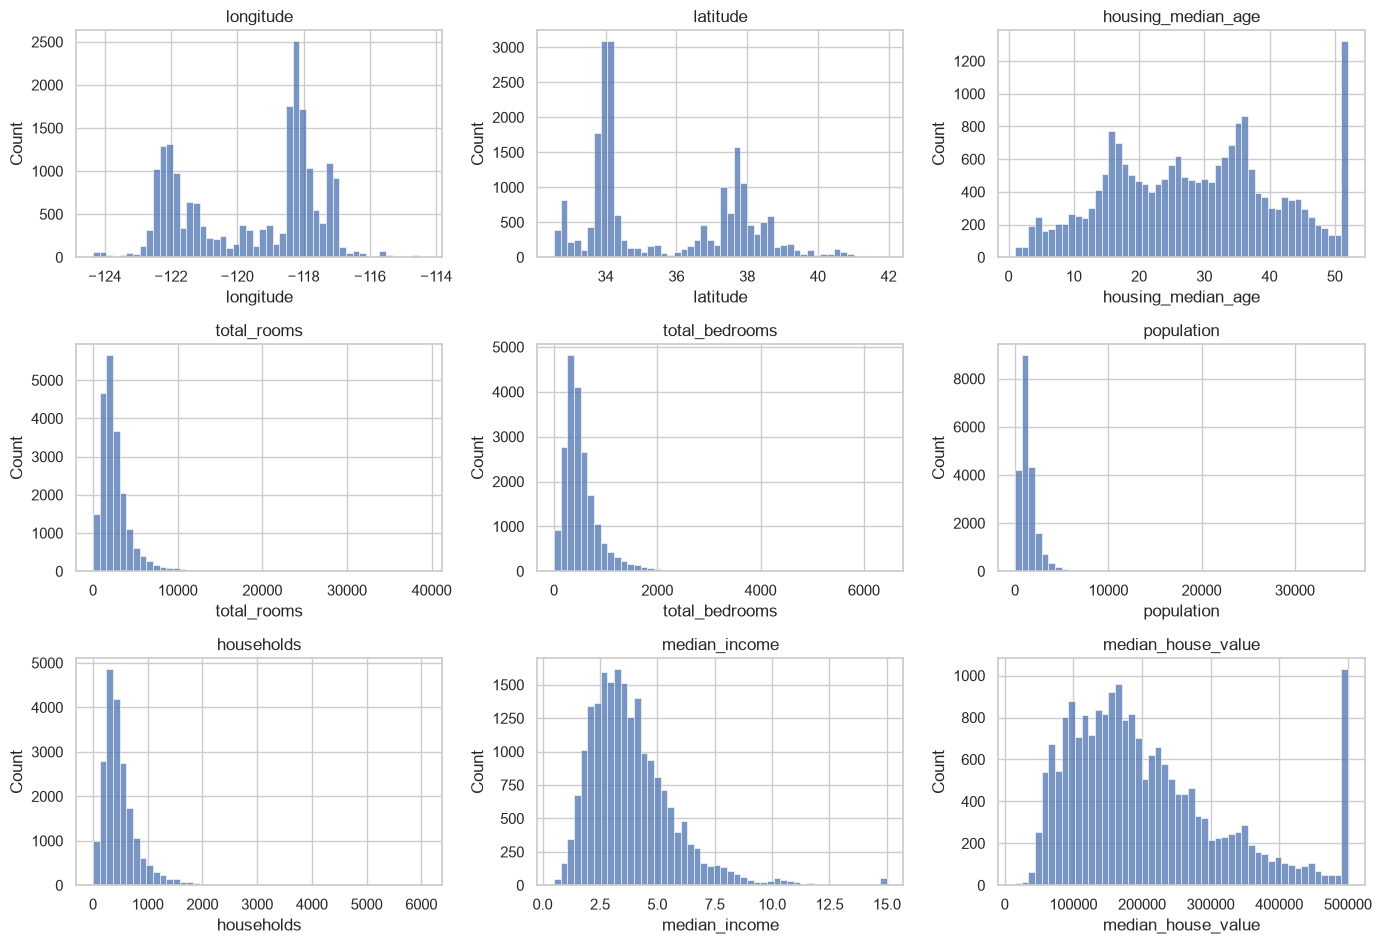

In [3]:
cols = ["housing_median_age", "total_rooms", "total_bedrooms", "population",
        "households", "median_income", "median_house_value"]

# Punto 6: promedio de cada columna por categoría de ocean_proximity
display(df.groupby("ocean_proximity")[cols].mean())

# Punto 7: histograma de cada variable numérica
num_eda = df.select_dtypes("number").columns
filas = ceil(len(num_eda) / 3)
fig, axes = plt.subplots(filas, 3, figsize=(14, 3.2 * filas))
for ax, c in zip(axes.ravel(), num_eda):
    sns.histplot(df[c], bins=50, ax=ax); ax.set_title(c)
for ax in axes.ravel()[len(num_eda):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### Diagrama de caja e IQR

Se identifican posibles valores atípicos mediante el rango intercuartílico (IQR). El criterio utilizado es el del enunciado del laboratorio.

Q1=66.0, Q2=70.0, Q3=75.0, IQR=9.0, límites=(52.5, 88.5)


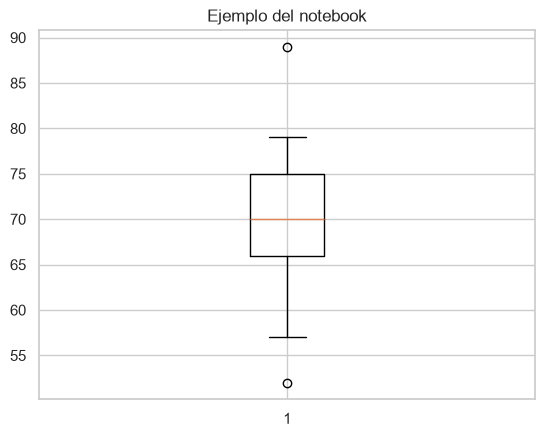

,lim_inf,lim_sup,n_fuera,% fuera
longitude,-127.4850,-112.3250,0.0000,0.0000
latitude,28.2600,43.3800,0.0000,0.0000
housing_median_age,-10.5000,65.5000,0.0000,0.0000
total_rooms,"-1,102.6250","5,698.3750","1,287.0000",6.2355
total_bedrooms,-230.5000,"1,173.5000","1,271.0000",6.1579
population,-620.0000,"3,132.0000","1,196.0000",5.7946
households,-207.5000,"1,092.5000","1,220.0000",5.9109
median_income,-0.7064,8.0130,681.0000,3.2994
median_house_value,"-98,087.5000","482,412.5000","1,071.0000",5.1890


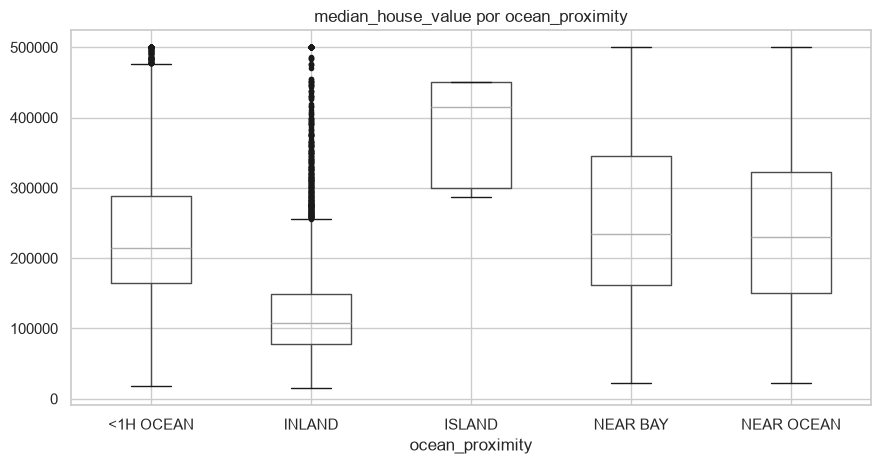

In [4]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
q1, q2, q3 = np.percentile(T, [25, 50, 75], method="weibull")
IQR = q3 - q1
print(f"Q1={q1}, Q2={q2}, Q3={q3}, IQR={IQR}, límites=({q1-1.5*IQR}, {q3+1.5*IQR})")
plt.boxplot(T); plt.title("Ejemplo del notebook"); plt.show()

def limites_iqr(s):
    a, b = s.quantile([.25, .75]); iqr = b - a
    return a - 1.5 * iqr, b + 1.5 * iqr

filas_out = {}
for c in num_eda:
    lo, hi = limites_iqr(df[c].dropna())
    n_fuera = int(((df[c] < lo) | (df[c] > hi)).sum())
    filas_out[c] = {"lim_inf": lo, "lim_sup": hi, "n_fuera": n_fuera, "% fuera": 100 * n_fuera / len(df)}
display(pd.DataFrame(filas_out).T)

# Punto 8: boxplot del valor por categoría
df.boxplot(column="median_house_value", by="ocean_proximity", sym="k.", figsize=(10, 5))
plt.suptitle(""); plt.title("median_house_value por ocean_proximity"); plt.show()

### Correlación, pairplot y scatter (puntos 9–11)

Se analizan las asociaciones lineales entre variables y la distribución geográfica de los valores de las viviendas.

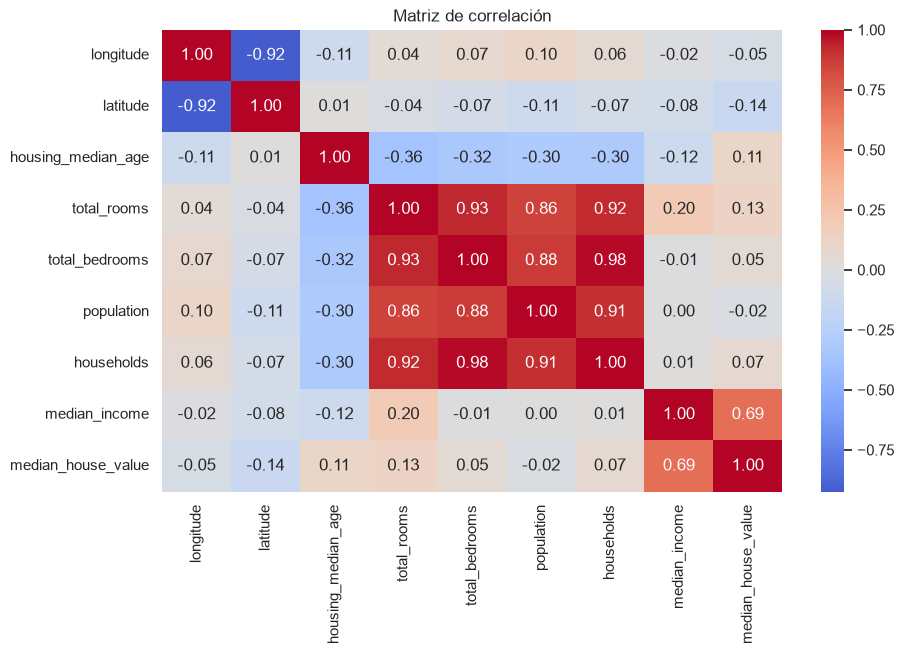

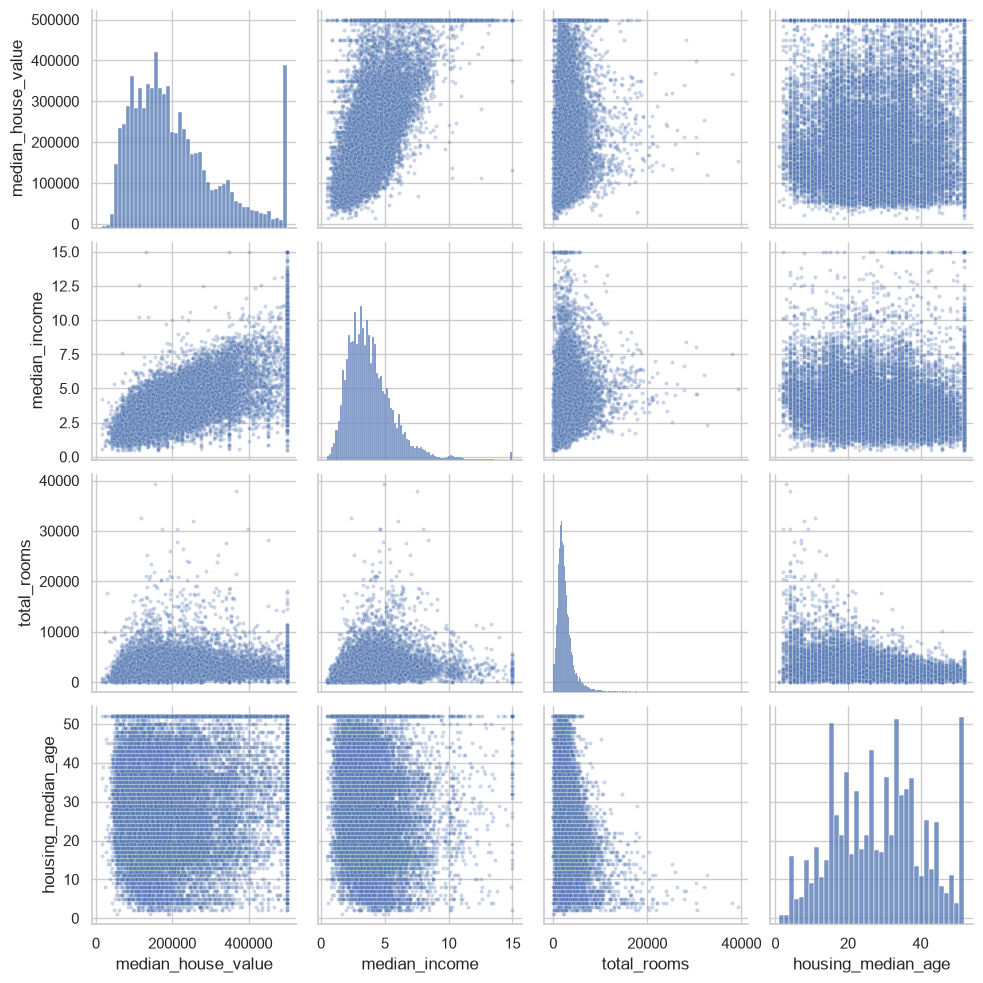

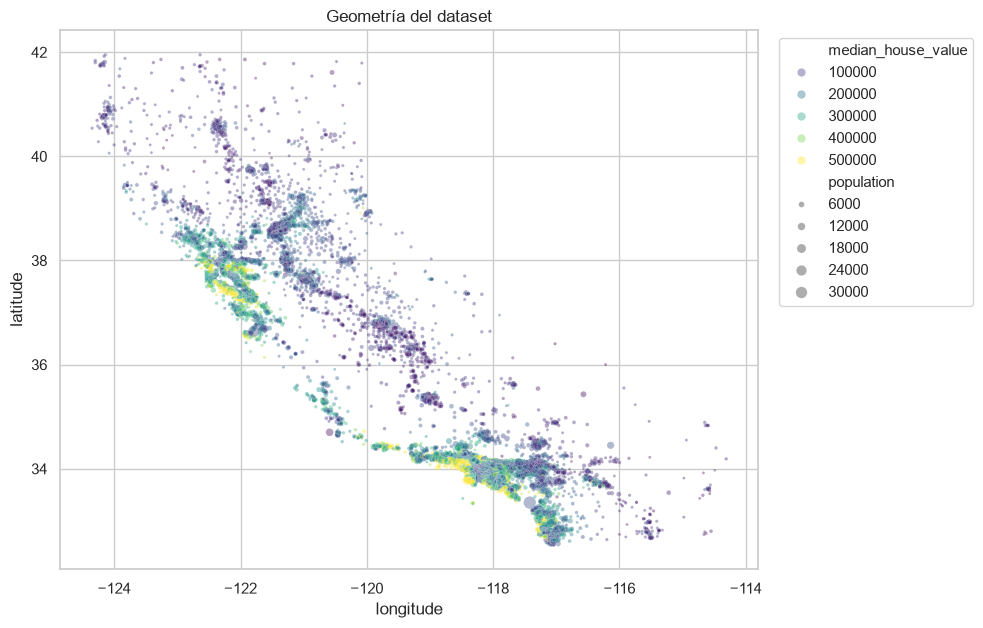

In [5]:
corr_matrix = df.corr(numeric_only=True)          # punto 9
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación"); plt.show()

sns.pairplot(df[["median_house_value", "median_income", "total_rooms", "housing_median_age"]],
             plot_kws={"alpha": .3, "s": 8})        # punto 10
plt.show()

plt.figure(figsize=(9, 7))                           # punto 11
sns.scatterplot(data=df, x="longitude", y="latitude", hue="median_house_value",
                size="population", sizes=(4, 80), alpha=.4, palette="viridis")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.title("Geometría del dataset"); plt.show()

**Puntos 9–11 — Resultados:** las correlaciones más altas entre variables numéricas son:

- `total_bedrooms`–`households`: **0,98**
- `total_rooms`–`total_bedrooms`: **0,93**
- `total_rooms`–`households`: **0,92**
- `population`–`households`: **0,91**
- `total_bedrooms`–`population`: **0,88**
- `total_rooms`–`population`: **0,86**
- `longitude`–`latitude`: **−0,92**

La variable que presenta la mayor correlación con `median_house_value` es **`median_income`**, con **r = 0,69**.

Geográficamente, los valores altos de `median_house_value` se concentran principalmente en zonas costeras y alrededor de los principales núcleos urbanos, mientras que en zonas más interiores predominan valores menores. También se observa una clara estructura espacial de las observaciones.

# 2.0 Preparación del data frame (puntos 12–17)

## Partición: data snooping y sampling bias (puntos 12–13)

Se compara una partición aleatoria con una partición estratificada según `income_cat`.

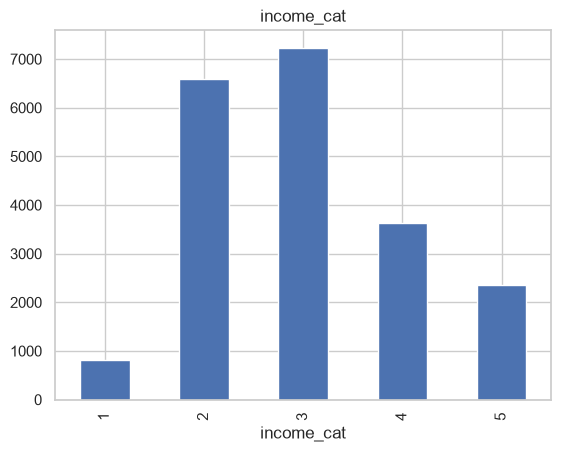

16512 4128


,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.0398,0.0400,0.0402,0.9732,0.3650
2,0.3188,0.3188,0.3244,1.7323,0.0152
3,0.3506,0.3505,0.3585,2.2664,0.0138
4,0.1763,0.1764,0.1674,5.0563,0.0275
5,0.1144,0.1143,0.1095,4.3184,0.0847


In [6]:
df["income_cat"] = pd.cut(df["median_income"], bins=[0., 1.5, 3.0, 4.5, 6., np.inf], labels=[1, 2, 3, 4, 5])
df["income_cat"].value_counts().sort_index().plot(kind="bar", title="income_cat"); plt.show()

# Punto 12: partición aleatoria
train_set, test_set = train_test_split(df, test_size=0.2, random_state=RS)
print(len(train_set), len(test_set))

# Punto 13: partición estratificada por income_cat
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RS)
for tr_idx, te_idx in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[tr_idx].copy()
    strat_test_set = df.loc[te_idx].copy()

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"]  = abs(100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)
display(compare_props)

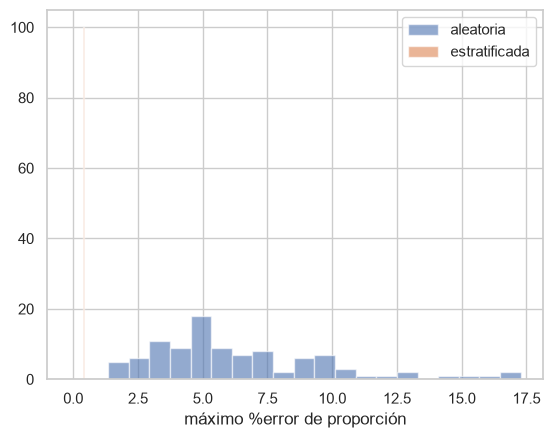

In [7]:
ref = income_cat_proportions(df)
e_rand, e_strat = [], []
for seed in range(100):
    _, te = train_test_split(df, test_size=0.2, random_state=seed)
    e_rand.append((100 * income_cat_proportions(te) / ref - 100).abs().max())
    _, ti = next(StratifiedShuffleSplit(1, test_size=0.2, random_state=seed).split(df, df["income_cat"]))
    e_strat.append((100 * income_cat_proportions(df.loc[ti]) / ref - 100).abs().max())

plt.hist(e_rand, bins=20, alpha=.6, label="aleatoria"); plt.hist(e_strat, bins=20, alpha=.6, label="estratificada")
plt.xlabel("máximo %error de proporción"); plt.legend(); plt.show()

**Puntos 12–13 — Resultados:** la partición aleatoria reproduce las proporciones generales de `income_cat`, pero presenta errores porcentuales mayores. En el conjunto de prueba, los errores máximos por categoría alcanzan **5,06 %** en la partición aleatoria, frente a **0,37 %** en la estratificada.

La partición estratificada es más estable porque conserva explícitamente la distribución de `income_cat` entre entrenamiento y prueba. Después de la partición, `income_cat` se elimina porque solo se utilizó como variable de estratificación.

## Feature engineering, limpieza y categóricas (puntos 13–16)

Se incorporan las variables `rooms_per_household`, `bedrooms_per_room` y `population_per_household`, además de la codificación One-Hot de `ocean_proximity`. Los valores faltantes se imputan posteriormente utilizando únicamente el conjunto de entrenamiento.

In [8]:
def add_ratios(d):
    d = d.copy()
    d["rooms_per_household"]      = d["total_rooms"] / d["households"]
    d["bedrooms_per_room"]        = d["total_bedrooms"] / d["total_rooms"]
    d["population_per_household"] = d["population"] / d["households"]
    return d

ratio_cols = ["rooms_per_household", "bedrooms_per_room", "population_per_household"]

strat_train_set = add_ratios(strat_train_set).drop(columns="income_cat")
strat_test_set  = add_ratios(strat_test_set).drop(columns="income_cat")

y_train = strat_train_set["median_house_value"]; X_train = strat_train_set.drop(columns="median_house_value")
y_test  = strat_test_set["median_house_value"];  X_test  = strat_test_set.drop(columns="median_house_value")

num_cols = X_train.select_dtypes("number").columns.tolist()   # 8 originales + 3 razones
cat_cols = ["ocean_proximity"]
print(len(X_train), len(X_test), "| numéricas:", len(num_cols))
display(X_train[ratio_cols].describe().T)

16512 4128 | numéricas: 11


,count,mean,std,min,25%,50%,75%,max
rooms_per_household,"16,512.0000",5.4404,2.6117,1.1304,4.4422,5.2323,6.0564,141.9091
bedrooms_per_room,"16,354.0000",0.2129,0.0574,0.1000,0.1753,0.2030,0.2398,1.0000
population_per_household,"16,512.0000",3.0965,11.5848,0.6923,2.4314,2.8177,3.2814,"1,243.3333"


In [9]:
# Punto 14: imputer ajustado SOLO con train; compara media vs mediana
imp = SimpleImputer(strategy="median").fit(X_train[num_cols])
display(pd.DataFrame({"media": X_train[num_cols].mean(), "mediana": X_train[num_cols].median()}))

,media,mediana
longitude,-119.5756,-118.5100
latitude,35.6393,34.2600
housing_median_age,28.6534,29.0000
total_rooms,"2,622.5398","2,119.0000"
total_bedrooms,534.9146,433.0000
population,"1,419.6874","1,164.0000"
households,497.0118,408.0000
median_income,3.8759,3.5415
rooms_per_household,5.4404,5.2323
bedrooms_per_room,0.2129,0.2030


**Punto 14 — Resultados:** las diferencias más marcadas entre media y mediana aparecen en las variables de conteo y en `population_per_household`. Por ejemplo:

- `total_rooms`: media **2622,54**, mediana **2119,00**.
- `total_bedrooms`: media **534,91**, mediana **433,00**.
- `population`: media **1419,69**, mediana **1164,00**.
- `households`: media **497,01**, mediana **408,00**.
- `population_per_household`: media **3,10**, mediana **2,82**.

Estas diferencias indican distribuciones asimétricas y presencia de valores extremos. Por ello se utiliza la **mediana**, que es menos sensible a los valores atípicos que la media.

**Punto 15:** `ocean_proximity` se transforma mediante One-Hot Encoding en cinco variables binarias.

In [10]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(X_train[cat_cols])
print(ohe.categories_)

def a_matriz(X):
    num = pd.DataFrame(imp.transform(X[num_cols]), columns=num_cols, index=X.index)
    cat = pd.DataFrame(ohe.transform(X[cat_cols]), columns=ohe.categories_[0], index=X.index)
    return pd.concat([num, cat], axis=1)

Xtr_raw, Xte_raw = a_matriz(X_train), a_matriz(X_test)

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


## Escalamiento y data frames finales (puntos 16–17)

Se aplica `MinMaxScaler` ajustado únicamente con el conjunto de entrenamiento. El resultado contiene 17 variables en total, sin valores faltantes.

In [11]:
scaler = MinMaxScaler().fit(Xtr_raw)
Xtr = pd.DataFrame(scaler.transform(Xtr_raw), columns=Xtr_raw.columns, index=Xtr_raw.index)
Xte = pd.DataFrame(scaler.transform(Xte_raw), columns=Xte_raw.columns, index=Xte_raw.index)

housing_train = Xtr.assign(median_house_value=y_train)   # características + etiqueta
housing_test  = Xte.assign(median_house_value=y_test)
print(housing_train.shape, housing_test.shape, "| NaN en train:", int(housing_train.isna().sum().sum()))
display(housing_train.head())

(16512, 17) (4128, 17) | NaN en train: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
12655,0.2878,0.6355,0.5490,0.0984,0.1281,0.0626,0.1314,0.1154,0.0309,0.1175,0.0020,0.0000,1.0000,0.0000,0.0000,0.0000,"72,100.0000"
15502,0.7092,0.0584,0.1176,0.1352,0.1374,0.0564,0.1430,0.4026,0.0412,0.0675,0.0016,0.0000,0.0000,0.0000,0.0000,1.0000,"279,600.0000"
2908,0.5289,0.3007,0.8431,0.0410,0.0496,0.0186,0.0556,0.1638,0.0303,0.1018,0.0012,0.0000,1.0000,0.0000,0.0000,0.0000,"82,700.0000"
14053,0.7191,0.0223,0.4510,0.0476,0.0833,0.0251,0.0898,0.1191,0.0196,0.1961,0.0009,0.0000,0.0000,0.0000,0.0000,1.0000,"112,500.0000"
20496,0.5627,0.1849,0.5098,0.0898,0.1037,0.0514,0.1079,0.2756,0.0353,0.0919,0.0020,1.0000,0.0000,0.0000,0.0000,0.0000,"238,300.0000"


# Regresión lineal base (puntos 18–22)

Se ajusta una regresión lineal y se evalúa mediante validación cruzada dentro del conjunto de entrenamiento.

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=RS)
SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}

def cv_resumen(modelo, X, y, nombre):
    r = cross_validate(modelo, X, y, cv=cv, scoring=SCORING, return_train_score=True, n_jobs=-1)
    return pd.Series({"R2_train": r["train_r2"].mean(), "R2_cv": r["test_r2"].mean(),
                      "R2_cv_std": r["test_r2"].std(),
                      "RMSE_train": -r["train_rmse"].mean(), "RMSE_cv": -r["test_rmse"].mean(),
                      "MAE_cv": -r["test_mae"].mean()}, name=nombre)

lr = LinearRegression().fit(Xtr, y_train)
tabla_base = pd.DataFrame([cv_resumen(LinearRegression(), Xtr, y_train, "OLS (punto 17)")])
display(tabla_base)
display(pd.Series(lr.coef_, index=Xtr.columns, name="coeficiente (features en [0,1])").sort_values())

,R2_train,R2_cv,R2_cv_std,RMSE_train,RMSE_cv,MAE_cv
OLS (punto 17),0.6532,0.6490,0.0083,"68,129.1273","68,536.3638","49,191.2196"


population                 -1,474,779.5854
longitude                    -281,104.2032
latitude                     -249,380.5371
INLAND                        -51,777.5783
NEAR BAY                      -22,255.1016
<1H OCEAN                     -17,551.7251
NEAR OCEAN                    -14,160.6617
total_bedrooms                  4,878.2775
housing_median_age             56,504.3184
population_per_household       97,977.1205
ISLAND                        105,745.0666
total_rooms                   147,009.0861
bedrooms_per_room             265,689.1287
rooms_per_household           392,319.4197
median_income                 595,767.0516
households                    611,531.2418
Name: coeficiente (features en [0,1]), dtype: float64

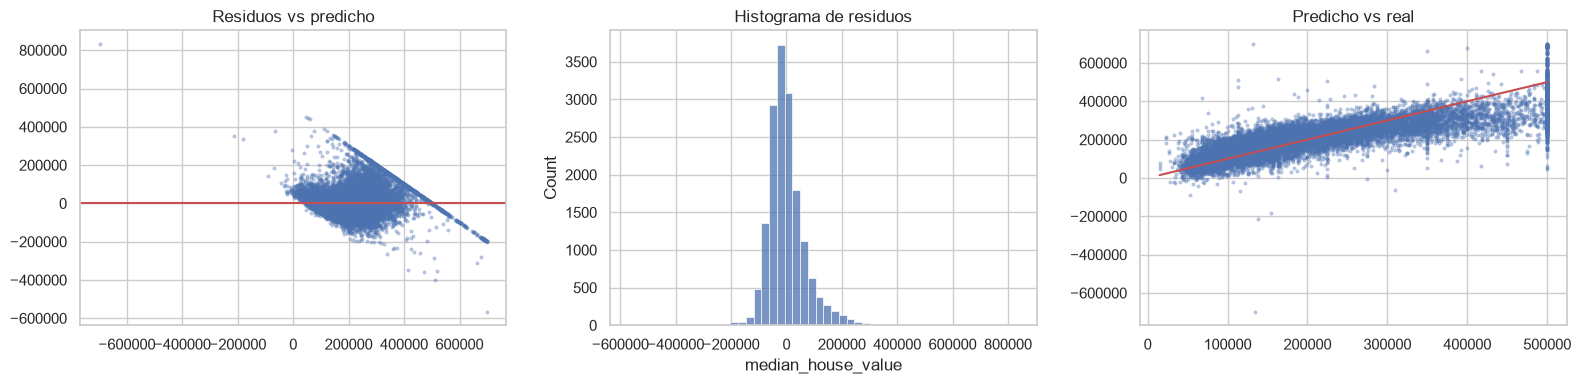

In [13]:
# Punto 19: ¿es válido el supuesto lineal? Diagnóstico de residuos (sobre train)
pred_tr = lr.predict(Xtr); resid = y_train - pred_tr
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].scatter(pred_tr, resid, s=4, alpha=.3); ax[0].axhline(0, color="r"); ax[0].set_title("Residuos vs predicho")
sns.histplot(resid, bins=50, ax=ax[1]); ax[1].set_title("Histograma de residuos")
ax[2].scatter(y_train, pred_tr, s=4, alpha=.3); ax[2].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], "r")
ax[2].set_title("Predicho vs real"); plt.tight_layout(); plt.show()

**Puntos 18–20 — Resultados**

**18. Generalización:** el modelo obtiene **R² = 0,6532** en train y **R² = 0,6490** en validación cruzada, con una diferencia de solo **0,0042**. No se observa una señal importante de sobreajuste en esta comparación, aunque el modelo todavía deja una fracción considerable de la variabilidad sin explicar.

**19. Diagnóstico de residuos:** los residuos muestran una dispersión que cambia con el valor predicho y una estructura no completamente aleatoria. Además, en `predicho vs. real` aparece una banda horizontal asociada al límite superior de `median_house_value` (500 001 USD). Esto evidencia heterocedasticidad y el efecto del techo de la variable objetivo; también se observan desviaciones de la relación lineal.

**20. Interpretación del R²:** el **R² de CV = 0,6490** indica que el modelo explica aproximadamente el **64,9 % de la variabilidad** de `median_house_value` respecto al predictor constante que siempre utiliza la media de `y`. No implica causalidad.

Los errores de validación cruzada son **RMSE = 68 536,38 USD** y **MAE = 49 191,26 USD**.

## Punto 22: automatizar con Pipeline + ColumnTransformer

El `Pipeline` integra imputación, escalamiento, codificación y regresión, de modo que estas transformaciones se reajustan dentro de cada partición de la validación cruzada.

In [14]:
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", MinMaxScaler())]), num_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
])
pipe_ols = Pipeline([("pre", pre), ("lr", LinearRegression())])

# Verificación: el pipeline reproduce exactamente la construcción manual
print("Pipeline == construcción manual:", np.allclose(clone(pre).fit(X_train).transform(X_train), Xtr.to_numpy()))

tabla_base = pd.DataFrame([cv_resumen(pipe_ols, X_train, y_train, "OLS en Pipeline (sin fuga)")])
display(tabla_base)

Pipeline == construcción manual: True


,R2_train,R2_cv,R2_cv_std,RMSE_train,RMSE_cv,MAE_cv
OLS en Pipeline (sin fuga),0.6532,0.6490,0.0083,"68,129.1249","68,536.3769","49,191.2603"


**Punto 21 — Resultado:** sí, el problema puede ajustarse con otra transformación del objetivo. Se probó `log(y)`, pero en este conjunto produjo un desempeño inferior al modelo lineal original: **R² CV = 0,4056** frente a **0,6490**, con **RMSE CV = 89 053,12 USD** frente a **68 536,38 USD**. Por tanto, esta transformación no mejora el modelo en estos datos.

In [15]:
pipe_log = Pipeline([("pre", pre), ("lr", TransformedTargetRegressor(LinearRegression(), func=np.log, inverse_func=np.exp))])
display(pd.DataFrame([cv_resumen(pipe_ols, X_train, y_train, "OLS"),
                      cv_resumen(pipe_log, X_train, y_train, "OLS con log(y)")]))

,R2_train,R2_cv,R2_cv_std,RMSE_train,RMSE_cv,MAE_cv
OLS,0.6532,0.6490,0.0083,"68,129.1249","68,536.3769","49,191.2603"
OLS con log(y),0.4221,0.4056,0.0603,"87,946.7353","89,053.1218","51,266.8676"


# 3.0 Modelo base interpretable con PCA (punto 23)

Se construye PCA sobre las variables numéricas estandarizadas y se determina el número de componentes necesario para alcanzar el 80 % de varianza explicada.

### 23.a Componentes desde la covarianza (verificado a mano)

Autovalores propios == sklearn: True


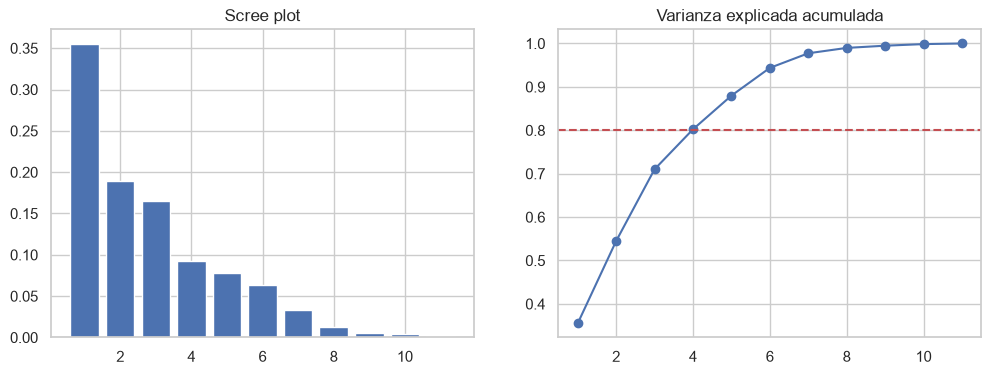

Componentes que alcanzan 80%: K = 4 (varianza acumulada = 0.802)


In [16]:
Xi = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_train[num_cols]), columns=num_cols)
Z = StandardScaler().fit_transform(Xi)                 # paso 1: centrar y estandarizar
S = np.cov(Z, rowvar=False)                            # paso 2: Σ
lam, V = np.linalg.eigh(S); o = lam.argsort()[::-1]; lam, V = lam[o], V[:, o]   # paso 3
pca_full = PCA().fit(Z)
print("Autovalores propios == sklearn:", np.allclose(lam, pca_full.explained_variance_))

cum = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(lam) + 1), pca_full.explained_variance_ratio_); ax[0].set_title("Scree plot")
ax[1].plot(range(1, len(cum) + 1), cum, "o-"); ax[1].axhline(0.80, ls="--", color="r"); ax[1].set_title("Varianza explicada acumulada")
plt.show()

UMBRAL = 0.80        # umbral de varianza explicada para seleccionar K
K = int(np.searchsorted(cum, UMBRAL)) + 1
print(f"Componentes que alcanzan {UMBRAL:.0%}: K = {K} (varianza acumulada = {cum[K-1]:.3f})")

### 23.b Cargas y relación con los puntos 9 y 10

Se comparan las cargas de las componentes principales con los grupos de variables identificados mediante la matriz de correlación.

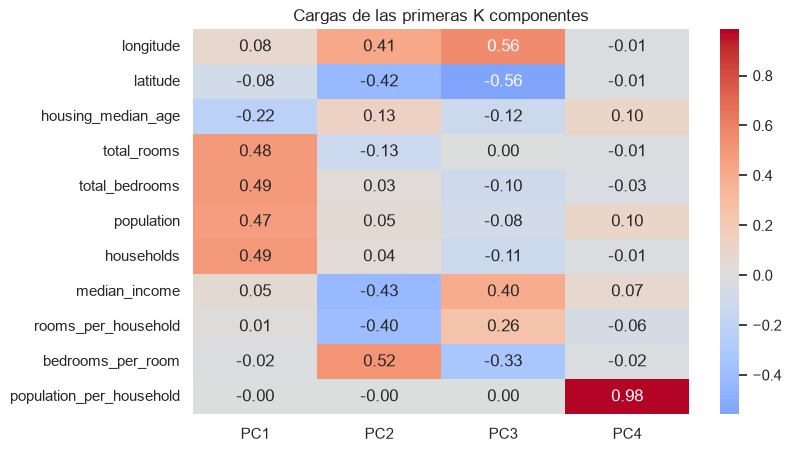

In [17]:
cargas = pd.DataFrame(pca_full.components_.T, index=num_cols, columns=[f"PC{i+1}" for i in range(len(num_cols))])
plt.figure(figsize=(8, 5)); sns.heatmap(cargas.iloc[:, :K], annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cargas de las primeras K componentes"); plt.show()

**Resultado:** 

- **PC1** está dominada por `total_rooms`, `total_bedrooms`, `population` y `households`, con cargas cercanas a 0,47–0,49. Resume principalmente el **tamaño del distrito**.
- **PC2** combina principalmente `bedrooms_per_room`, `median_income`, `latitude` y `rooms_per_household`.
- **PC3** está dominada por `longitude` y `latitude`, junto con `median_income`, y recoge buena parte del **patrón geográfico**.
- **PC4** está casi completamente asociada con `population_per_household` (carga ≈ **0,98**).

Sí existe correspondencia con la matriz de correlación: las variables de conteo altamente correlacionadas se agrupan en PC1 y las variables geográficas aparecen principalmente en PC2–PC3. El signo de una componente puede cambiar sin modificar su significado físico/matemático.

In [18]:
filas = {}
for nombre, sc in [("MinMax", MinMaxScaler()), ("Standard", StandardScaler())]:
    p = PCA().fit(sc.fit_transform(Xi))
    filas[nombre] = pd.Series(p.explained_variance_ratio_[:5], index=[f"PC{i+1}" for i in range(5)])
display(pd.DataFrame(filas).T)

,PC1,PC2,PC3,PC4,PC5
MinMax,0.4742,0.3340,0.1018,0.0587,0.0179
Standard,0.3549,0.1898,0.1655,0.0921,0.0776


**Resultado:** la varianza explicada cambia de forma apreciable según el escalador:

| Escalador | PC1 | PC2 | PC3 | PC4 | PC5 |
|---|---:|---:|---:|---:|---:|
| MinMax | 0,4742 | 0,3340 | 0,1018 | 0,0587 | 0,0179 |
| Standard | 0,3549 | 0,1898 | 0,1655 | 0,0921 | 0,0776 |

Se utiliza **`StandardScaler`** porque las variables tienen escalas y unidades muy diferentes. Al estandarizarlas, ninguna variable domina las direcciones principales únicamente por su escala.

In [19]:
def make_pca_pipe(feats, k):
    pre_n = ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                 ("sc", StandardScaler())]), feats)])
    return Pipeline([("pre", pre_n), ("pca", PCA(n_components=k)), ("lr", LinearRegression())])

pipe_pca = make_pca_pipe(num_cols, K)
tabla_pca = pd.DataFrame([cv_resumen(pipe_ols, X_train, y_train, "OLS completo (punto 17/20)"),
                          cv_resumen(pipe_pca, X_train, y_train, f"PCA K={K} + OLS")])
display(tabla_pca)
print("R² perdido por usar solo", K, "componentes:",
      round(tabla_pca.loc["OLS completo (punto 17/20)", "R2_cv"] - tabla_pca.iloc[1]["R2_cv"], 4))

,R2_train,R2_cv,R2_cv_std,RMSE_train,RMSE_cv,MAE_cv
OLS completo (punto 17/20),0.6532,0.6490,0.0083,"68,129.1249","68,536.3769","49,191.2603"
PCA K=4 + OLS,0.2006,0.0194,0.3477,"103,442.8291","113,184.6533","81,083.0795"


R² perdido por usar solo 4 componentes: 0.6296


### 23.e ¿Las razones aportan información que las componentes no capturan?

Se compara la capacidad de las componentes para reconstruir las variables de razón y su relación con los residuos del modelo reducido.

In [20]:
feats_orig = [c for c in num_cols if c not in ratio_cols]
pipe_orig = make_pca_pipe(feats_orig, K)
print("R² CV (K comps, solo originales):", round(cross_val_score(pipe_orig, X_train, y_train, cv=cv, scoring="r2").mean(), 4))
print("R² CV (K comps, originales + razones):", round(cross_val_score(pipe_pca, X_train, y_train, cv=cv, scoring="r2").mean(), 4))

pipe_orig.fit(X_train, y_train)
sc_orig = pipe_orig[:-1].transform(X_train)
res_orig = (y_train - pipe_orig.predict(X_train)).to_numpy()
filas = {}
for f in ratio_cols:
    filas[f] = {"R2 reconstrucción desde PCs": LinearRegression().fit(sc_orig, Xi[f]).score(sc_orig, Xi[f]),
                "corr con residuo": np.corrcoef(Xi[f], res_orig)[0, 1]}
display(pd.DataFrame(filas).T)

R² CV (K comps, solo originales): 0.5239
R² CV (K comps, originales + razones): 0.0194


,R2 reconstrucción desde PCs,corr con residuo
rooms_per_household,0.1309,-0.0600
bedrooms_per_room,0.4297,0.2232
population_per_household,0.0006,-0.0534


### 23.f Test de permutaciones: ¿el modelo reducido captura algo real?

Se compara el R² observado con la distribución obtenida al permutar aleatoriamente `y`.

R² observado (CV) = 0.0194 | p-value = 0.0050 (B = 200)


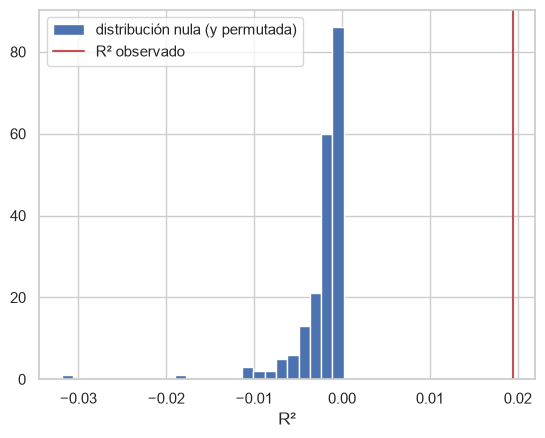

In [21]:
score_obs, perm_scores, pval = permutation_test_score(
    pipe_pca, X_train, y_train, cv=cv, scoring="r2",
    n_permutations=N_PERM, random_state=RS, n_jobs=-1)
print(f"R² observado (CV) = {score_obs:.4f} | p-value = {pval:.4f} (B = {N_PERM})")
plt.hist(perm_scores, bins=25, label="distribución nula (y permutada)")
plt.axvline(score_obs, color="r", label="R² observado"); plt.legend(); plt.xlabel("R²"); plt.show()

### 23.g Comparación de coeficientes

Se expresan los coeficientes del PCR equivalente en las variables originales estandarizadas para facilitar la comparación con OLS.

In [22]:
pipe_pca.fit(X_train, y_train)
ols_std = Pipeline([("pre", ColumnTransformer([("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                                                  ("sc", StandardScaler())]), num_cols)])),
                    ("lr", LinearRegression())]).fit(X_train, y_train)

beta_pcr = pipe_pca["pca"].components_.T @ pipe_pca["lr"].coef_
display(pd.DataFrame({"OLS (estandarizado)": ols_std["lr"].coef_, "PCR equivalente": beta_pcr}, index=num_cols))
print("Coeficientes del modelo reducido sobre las componentes:", pipe_pca["lr"].coef_.round(1))

,OLS (estandarizado),PCR equivalente
longitude,"-82,966.0069","5,179.7793"
latitude,"-87,509.4687","-4,958.1730"
housing_median_age,"14,794.1043","-6,916.3147"
total_rooms,"6,636.5558","4,987.7045"
total_bedrooms,565.9785,"-1,799.1544"
population,"-46,637.7258","-1,188.0201"
households,"44,530.0062","-2,177.9461"
median_income,"80,532.9533","21,653.3579"
rooms_per_household,"7,997.4933","16,709.8331"
bedrooms_per_room,"18,978.4178","-21,661.1266"


Coeficientes del modelo reducido sobre las componentes: [  3820.2 -24644.8  26995.4   3268.4]


**Resultado:** con **K = 4** componentes, el R² de validación cruzada pasa de **0,6490** en OLS completo a **0,0194** en PCR, por lo que se pierde **0,6296** de R². El RMSE de CV aumenta de **68 536,38 USD** a **113 184,65 USD**.

El test de permutaciones produce **p = 0,0050**, por lo que el R² observado del modelo reducido es claramente superior al obtenido bajo la distribución nula de `y` permutada. Sin embargo, su capacidad predictiva es muy inferior a la del modelo completo.

Para interpretar variables concretas, **OLS es más directo**, porque cada coeficiente corresponde a una variable original. En PCR, cada coeficiente corresponde a una combinación lineal de variables, por lo que se gana compacidad pero se pierde interpretación directa.

# 4.0 Regularización: L2 vs. L1 (punto 24)

Se comparan Ridge (L2) y Lasso (L1), primero mediante una demostración del sobreajuste y luego mediante la variación de sus hiperparámetros.

### 24.a Aumentar la complejidad hasta sobreajustar

Se utiliza una submuestra del train y polinomios de grado creciente.

,n_términos,RMSE_train,RMSE_cv
grado,,,
1,15,"64,820.6481","65,724.4145"
2,135,"55,276.4693","66,346.6536"
3,815,"42,796.6997","659,855.2349"
4,3875,"30,572.0629","8,356,736.9607"


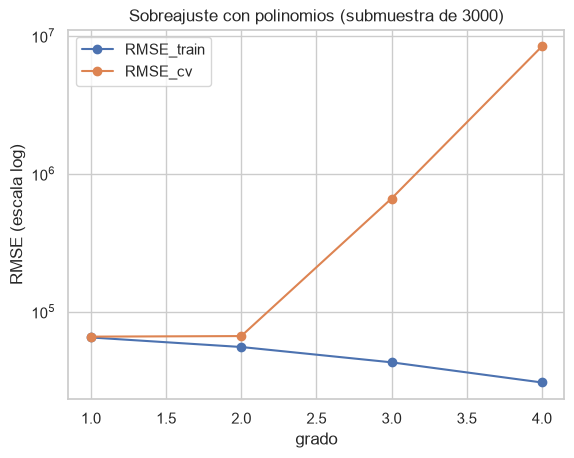

In [23]:
def curva_grado(X, y, grados):
    filas = []
    for d in grados:
        p = Pipeline([("pre", pre), ("poly", PolynomialFeatures(d, include_bias=False)), ("lr", LinearRegression())])
        r = cross_validate(p, X, y, cv=cv, scoring="neg_root_mean_squared_error", return_train_score=True, n_jobs=-1)
        nfeat = p.fit(X, y)[:-1].transform(X.iloc[:5]).shape[1]
        filas.append({"grado": d, "n_términos": nfeat, "RMSE_train": -r["train_score"].mean(), "RMSE_cv": -r["test_score"].mean()})
    return pd.DataFrame(filas).set_index("grado")

idx_sub = X_train.sample(N_SUB, random_state=RS).index
X_sub, y_sub = X_train.loc[idx_sub], y_train.loc[idx_sub]
curva_sub = curva_grado(X_sub, y_sub, range(1, GRAD_MAX + 1))
display(curva_sub)
curva_sub[["RMSE_train", "RMSE_cv"]].plot(marker="o", logy=True, title=f"Sobreajuste con polinomios (submuestra de {N_SUB})")
plt.ylabel("RMSE (escala log)"); plt.show()

**Resultado:** el sobreajuste aparece claramente a partir del **grado 3**. Entre grado 2 y 3, el RMSE de train baja de **55 276,47 USD** a **42 796,70 USD**, mientras que el RMSE de CV aumenta de **66 346,65 USD** a **659 855,23 USD**. En grado 4 el fenómeno se intensifica: train baja a **30 572,06 USD**, mientras CV sube a **8 356 736,96 USD**.

In [24]:
Xs = StandardScaler().fit_transform(Xtr_raw)           # variables estandarizadas (media 0)
yc = (y_train - y_train.mean()).to_numpy()
A, b = Xs.T @ Xs, Xs.T @ yc
alpha_demo = 1000.0
eta = 1 / (2 * (np.linalg.eigvalsh(A).max() + alpha_demo))   # paso seguro
beta = np.zeros(Xs.shape[1])
for _ in range(20000):
    beta = beta - eta * (-2 * (b - A @ beta) + 2 * alpha_demo * beta)

beta_sk = Ridge(alpha=alpha_demo, fit_intercept=False).fit(Xs, yc).coef_
print("factor de encogimiento por paso (1 - 2·η·α):", round(1 - 2 * eta * alpha_demo, 6))
print("máx |β_GD − β_Ridge| =", np.abs(beta - beta_sk).max())

factor de encogimiento por paso (1 - 2·η·α): 0.984811
máx |β_GD − β_Ridge| = 9.822542779147625e-11


### 24.c Evolución de coeficientes y error al variar α

Se examina el efecto de `α` sobre los coeficientes y sobre el RMSE de train y validación.

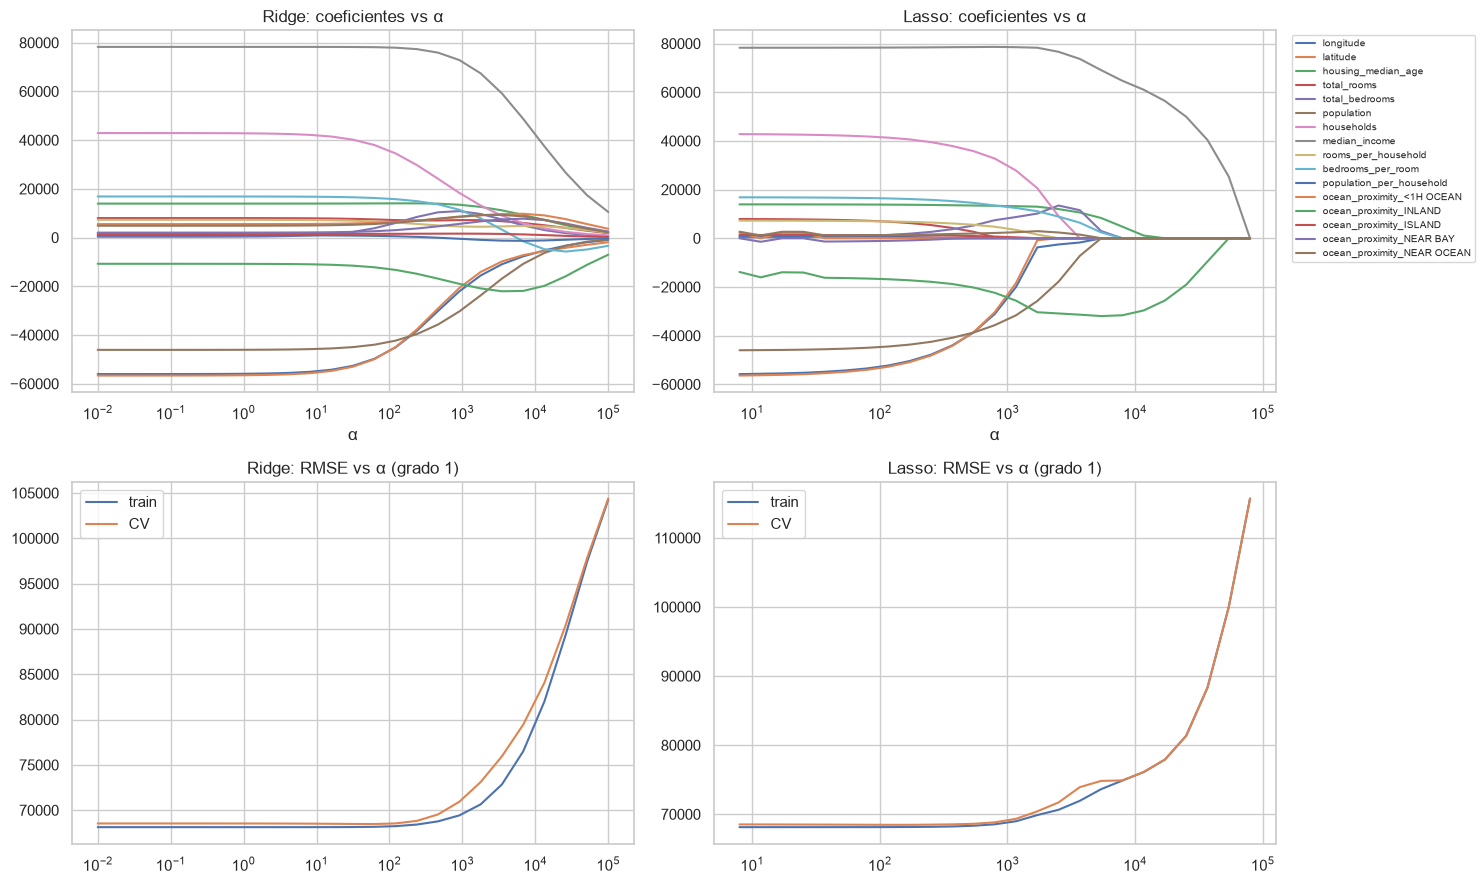

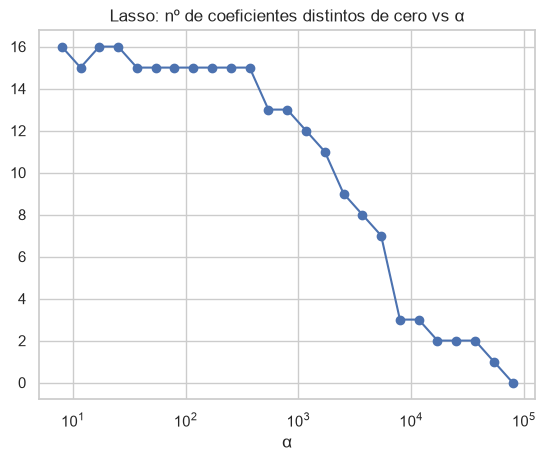

In [25]:
def pipe_reg(modelo, grado):
    return Pipeline([("pre", pre), ("poly", PolynomialFeatures(grado, include_bias=False)),
                     ("sc", StandardScaler()), ("m", modelo)])

def alpha_max(grado, X, y):
    Xp = pipe_reg(Lasso(), grado)[:-1].fit_transform(X)
    return np.abs(Xp.T @ (y.to_numpy() - y.mean())).max() / len(y)

def camino(make_model, grado, alphas, X, y):
    coefs, e_tr, e_cv = [], [], []
    for a in alphas:
        p = pipe_reg(make_model(a), grado)
        r = cross_validate(p, X, y, cv=cv, scoring="neg_root_mean_squared_error", return_train_score=True, n_jobs=-1)
        e_tr.append(-r["train_score"].mean()); e_cv.append(-r["test_score"].mean())
        coefs.append(p.fit(X, y)["m"].coef_)
    return np.array(coefs), np.array(e_tr), np.array(e_cv)

nombres = pipe_reg(Ridge(), 1).fit(X_train, y_train)[:-1].get_feature_names_out()
nombres = [n.split("__")[1] for n in nombres]

alphas_r = np.logspace(-2, 5, 25)
amax1 = alpha_max(1, X_train, y_train)
alphas_l = amax1 * np.logspace(-4, 0, 25)

C_r, tr_r, cv_r = camino(lambda a: Ridge(alpha=a), 1, alphas_r, X_train, y_train)
C_l, tr_l, cv_l = camino(lambda a: Lasso(alpha=a, max_iter=20000), 1, alphas_l, X_train, y_train)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
ax[0, 0].semilogx(alphas_r, C_r); ax[0, 0].set_title("Ridge: coeficientes vs α"); ax[0, 0].set_xlabel("α")
ax[0, 1].semilogx(alphas_l, C_l); ax[0, 1].set_title("Lasso: coeficientes vs α"); ax[0, 1].set_xlabel("α")
ax[0, 1].legend(nombres, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax[1, 0].semilogx(alphas_r, tr_r, label="train"); ax[1, 0].semilogx(alphas_r, cv_r, label="CV"); ax[1, 0].legend()
ax[1, 0].set_title("Ridge: RMSE vs α (grado 1)")
ax[1, 1].semilogx(alphas_l, tr_l, label="train"); ax[1, 1].semilogx(alphas_l, cv_l, label="CV"); ax[1, 1].legend()
ax[1, 1].set_title("Lasso: RMSE vs α (grado 1)")
plt.tight_layout(); plt.show()

plt.semilogx(alphas_l, (np.abs(C_l) > 1e-8).sum(axis=1), "o-")
plt.title("Lasso: nº de coeficientes distintos de cero vs α"); plt.xlabel("α"); plt.show()

In [ ]:
# Error vs α en el régimen de sobreajuste (grado 3, submuestra)
G = min(3, GRAD_MAX)
alphas_r3 = np.logspace(-1, 5, 12)
alphas_l3 = alpha_max(G, X_sub, y_sub) * np.logspace(-3, 0, 8)   # sin los α más pequeños (los más lentos)
_, tr_r3, cv_r3 = camino(lambda a: Ridge(alpha=a), G, alphas_r3, X_sub, y_sub)
_, tr_l3, cv_l3 = camino(lambda a: Lasso(alpha=a, max_iter=3000, tol=1e-3), G, alphas_l3, X_sub, y_sub)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a_, t_, c_, nm, axx in [(alphas_r3, tr_r3, cv_r3, "Ridge", ax[0]), (alphas_l3, tr_l3, cv_l3, "Lasso", ax[1])]:
    axx.semilogx(a_, t_, label="train"); axx.semilogx(a_, c_, label="CV")
    axx.axhline(curva_sub.loc[G, "RMSE_cv"], ls="--", color="gray", label="CV sin regularizar")
    axx.set_title(f"{nm}: polinomio grado {G} (submuestra)"); axx.set_xlabel("α"); axx.legend()
    axx.set_ylim(0, 300000)    
plt.tight_layout(); plt.show()

**Resultado:** para valores pequeños de `α`, train y CV presentan errores bajos y relativamente estables. Al aumentar demasiado la regularización, ambos errores crecen por el aumento del sesgo. El equilibrio se identifica mediante el mínimo del error de CV; en el camino analizado se obtienen aproximadamente **α = 61,9 para Ridge** y **α = 117 para Lasso**.

Ridge reduce los coeficientes de forma continua, mientras que Lasso puede llevar algunos exactamente a cero, produciendo una solución más dispersa.

In [ ]:
a_r = alphas_r[cv_r.argmin()]; a_l = alphas_l[cv_l.argmin()]
print(f"α Ridge = {a_r:.3g} | α Lasso = {a_l:.3g}")

m_ols = pipe_reg(LinearRegression(), 1).fit(X_train, y_train)["m"].coef_
m_rid = pipe_reg(Ridge(alpha=a_r), 1).fit(X_train, y_train)["m"].coef_
m_las = pipe_reg(Lasso(alpha=a_l, max_iter=20000), 1).fit(X_train, y_train)["m"].coef_
comp = pd.DataFrame({"OLS": m_ols, "Ridge": m_rid, "Lasso": m_las}, index=nombres)
display(comp)
colineales = ["total_rooms", "total_bedrooms", "population", "households"]
display(comp.loc[colineales])

α Ridge = 61.9 | α Lasso = 117


,OLS,Ridge,Lasso
longitude,"-56,046.3390","-49,785.7236","-52,271.7795"
latitude,"-56,657.8288","-49,966.2904","-52,772.6270"
housing_median_age,"13,931.5694","14,006.6098","13,815.2131"
total_rooms,"7,996.0630","7,445.6546","6,840.6712"
total_bedrooms,322.8038,"3,814.8108","1,362.0198"
population,"-46,114.1637","-44,000.8553","-44,470.1332"
households,"42,894.5071","37,996.4702","41,328.3987"
median_income,"78,265.1599","78,156.1764","78,338.1370"
rooms_per_household,"7,278.0069","6,630.7546","6,902.7640"
bedrooms_per_room,"16,859.1862","16,245.5756","16,367.9817"


,OLS,Ridge,Lasso
total_rooms,"7,996.0630","7,445.6546","6,840.6712"
total_bedrooms,322.8038,"3,814.8108","1,362.0198"
population,"-46,114.1637","-44,000.8553","-44,470.1332"
households,"42,894.5071","37,996.4702","41,328.3987"


**Resultado:** OLS distribuye el efecto entre variables fuertemente correlacionadas de manera inestable: `total_bedrooms` tiene un coeficiente de solo **322,8**, mientras `population` y `households` tienen coeficientes de **−46 114,2** y **42 894,5**, respectivamente.

Ridge redistribuye parcialmente estos coeficientes y reduce sus magnitudes: `total_bedrooms` pasa a **3814,8**, `population` a **−44 000,9** y `households` a **37 996,5**.

Lasso produce `total_bedrooms = 1362,0`, `population = −44 470,1` y `households = 41 328,4`. En este ajuste no anula ninguna de las cuatro variables de conteo analizadas. En el conjunto completo de variables, sí anula `ocean_proximity_<1H OCEAN`.

In [ ]:

cache_dir = tempfile.mkdtemp()      # caché del preprocesamiento (no depende de α)

def pipe_reg_c(modelo, grado):
    return Pipeline([("pre", pre), ("poly", PolynomialFeatures(grado, include_bias=False)),
                     ("sc", StandardScaler()), ("m", modelo)], memory=cache_dir)

cv_gs = KFold(n_splits=3, shuffle=True, random_state=RS)   # solo para elegir hiperparámetros

param_ridge = {"poly__degree": [1, 2], "m__alpha": np.logspace(-1, 5, 9)}
gs_ridge = GridSearchCV(pipe_reg_c(Ridge(), 2), param_ridge, cv=cv_gs,
                        scoring="neg_root_mean_squared_error", n_jobs=-1).fit(X_train, y_train)

amax2 = alpha_max(2, X_train, y_train)
param_lasso = {"poly__degree": [1, 2], "m__alpha": amax2 * np.logspace(-3, -0.5, 6)}
gs_lasso = GridSearchCV(pipe_reg_c(Lasso(max_iter=3000, tol=1e-3), 2), param_lasso, cv=cv_gs,
                        scoring="neg_root_mean_squared_error", n_jobs=-1).fit(X_train, y_train)

for nm, gs, param in [("Ridge", gs_ridge, param_ridge), ("Lasso", gs_lasso, param_lasso)]:
    g = param["m__alpha"]; best = gs.best_params_["m__alpha"]
    print(f"{nm}: mejores parámetros = {gs.best_params_} | RMSE CV = {-gs.best_score_:,.1f}")
    if best in (g.min(), g.max()):
        print("   AVISO: el mejor α está en el borde de la grilla; amplíala.")

Ridge: mejores parámetros = {'m__alpha': np.float64(100.0), 'poly__degree': 1} | RMSE CV = 68,520.5
Lasso: mejores parámetros = {'m__alpha': np.float64(251.40677745358042), 'poly__degree': 1} | RMSE CV = 68,485.8


# 5.0 Comparación final (punto 25)

En este punto se utiliza el conjunto de test. Los cuatro modelos se entrenan únicamente con train y sus hiperparámetros se seleccionaron mediante validación cruzada.

In [ ]:
pipe_ols.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)
modelos = {"OLS (pto 17)": pipe_ols, "PCA reducido": pipe_pca,
           "Ridge (mejor)": gs_ridge.best_estimator_, "Lasso (mejor)": gs_lasso.best_estimator_}
yt = y_test.to_numpy()
preds = {k: m.predict(X_test) for k, m in modelos.items()}

tabla_final = pd.DataFrame({k: {"R2": r2_score(yt, p), "RMSE": mean_squared_error(yt, p) ** .5,
                                "MAE": mean_absolute_error(yt, p)} for k, p in preds.items()}).T
display(tabla_final)

,R2,RMSE,MAE
OLS (pto 17),0.6576,"66,803.1389","48,966.3085"
PCA reducido,0.2055,"101,761.7199","79,950.6126"
Ridge (mejor),0.6575,"66,810.1085","48,936.8928"
Lasso (mejor),0.6576,"66,805.0534","48,909.7564"


### Bootstrap: diferencias frente a la regresión del punto 17

Se estiman intervalos de confianza para la diferencia de desempeño respecto a OLS mediante bootstrap pareado sobre el conjunto de test.

,ΔR2 medio,IC95 ΔR2 inf,IC95 ΔR2 sup,ΔRMSE medio,IC95 ΔRMSE inf,IC95 ΔRMSE sup,¿significativo?
PCA reducido,-0.4526,-0.4769,-0.4279,"34,965.3607","32,934.5533","36,927.2674",sí
Ridge (mejor),-0.0001,-0.0012,0.0011,5.8594,-108.0876,113.2191,no
Lasso (mejor),-0.0000,-0.0011,0.0012,0.9229,-116.9594,110.5171,no


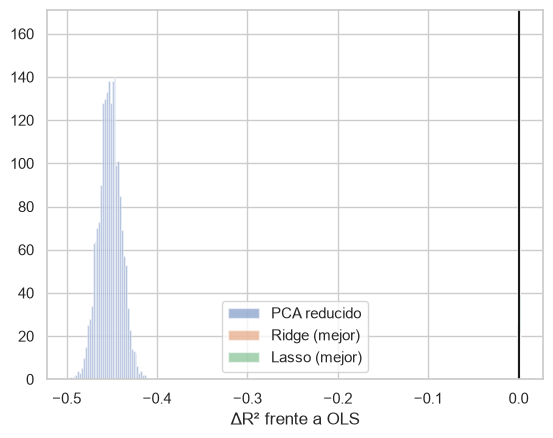

In [ ]:
def boot_pareado(yt, p_base, p_alt, B=B_BOOT, seed=RS):
    rng = np.random.default_rng(seed); n = len(yt)
    d_r2, d_rmse = np.empty(B), np.empty(B)
    for b in range(B):
        i = rng.integers(0, n, n)
        d_r2[b] = r2_score(yt[i], p_alt[i]) - r2_score(yt[i], p_base[i])
        d_rmse[b] = mean_squared_error(yt[i], p_alt[i]) ** .5 - mean_squared_error(yt[i], p_base[i]) ** .5
    return d_r2, d_rmse

filas, deltas = {}, {}
for k in ["PCA reducido", "Ridge (mejor)", "Lasso (mejor)"]:
    d_r2, d_rmse = boot_pareado(yt, preds["OLS (pto 17)"], preds[k]); deltas[k] = d_r2
    lo, hi = np.percentile(d_r2, [2.5, 97.5]); lo2, hi2 = np.percentile(d_rmse, [2.5, 97.5])
    filas[k] = {"ΔR2 medio": d_r2.mean(), "IC95 ΔR2 inf": lo, "IC95 ΔR2 sup": hi,
                "ΔRMSE medio": d_rmse.mean(), "IC95 ΔRMSE inf": lo2, "IC95 ΔRMSE sup": hi2,
                "¿significativo?": "sí" if (lo > 0 or hi < 0) else "no"}
display(pd.DataFrame(filas).T)

for k, d in deltas.items():
    plt.hist(d, bins=40, alpha=.5, label=k)
plt.axvline(0, color="k"); plt.xlabel("ΔR² frente a OLS"); plt.legend(); plt.show()

Se realiza además un bootstrap con re-entrenamiento: en cada réplica se remuestrea el train, se ajusta nuevamente el modelo con los hiperparámetros ya seleccionados y se evalúa sobre el mismo test.

In [ ]:
def boot_refit(modelo_base, B=B_REFIT, seed=RS):
    rng = np.random.default_rng(seed); n = len(X_train); out = np.empty(B)
    for b in range(B):
        i = rng.integers(0, n, n)
        m = clone(modelo_base).fit(X_train.iloc[i], y_train.iloc[i])
        out[b] = r2_score(yt, m.predict(X_test))
    return out

r2_boot = {k: boot_refit(m) for k, m in modelos.items()}
filas = {}
for k in ["PCA reducido", "Ridge (mejor)", "Lasso (mejor)"]:
    d = r2_boot[k] - r2_boot["OLS (pto 17)"]
    lo, hi = np.percentile(d, [2.5, 97.5])
    filas[k] = {"ΔR2 medio": d.mean(), "IC95 inf": lo, "IC95 sup": hi, "¿significativo?": "sí" if (lo > 0 or hi < 0) else "no"}
display(pd.DataFrame(filas).T)

,ΔR2 medio,IC95 inf,IC95 sup,¿significativo?
PCA reducido,-0.4489,-0.4622,-0.4328,sí
Ridge (mejor),0.0002,-0.0008,0.0016,no
Lasso (mejor),0.0002,-0.0011,0.0015,no


### ¿Las variables que conserva Lasso se relacionan con las que destacó PCA?

Se comparan las variables seleccionadas por Lasso con las variables de mayor carga en las primeras componentes de PCA.

In [ ]:
mejor_lasso = gs_lasso.best_estimator_
nom_l = mejor_lasso[:-1].get_feature_names_out()
coef_l = pd.Series(mejor_lasso["m"].coef_, index=nom_l)
print("Coeficientes ≠ 0:", int((coef_l.abs() > 1e-8).sum()), "de", len(coef_l))
display(coef_l[coef_l.abs() > 1e-8].abs().sort_values(ascending=False).head(15).rename("|coef| Lasso (mejores 15)"))

display(cargas.iloc[:, :K].abs().sort_values("PC1", ascending=False).rename_axis("variable"))

Coeficientes ≠ 0: 15 de 16


num__median_income                78,460.8475
num__latitude                     47,897.6921
num__longitude                    47,545.2224
num__population                   42,442.0937
num__households                   39,336.6806
cat__ocean_proximity_INLAND       17,954.7775
num__bedrooms_per_room            15,727.2790
num__housing_median_age           13,686.7926
num__rooms_per_household           6,447.7345
num__total_rooms                   5,194.6604
num__total_bedrooms                2,930.6847
cat__ocean_proximity_NEAR OCEAN    1,582.9582
cat__ocean_proximity_ISLAND        1,154.6717
cat__ocean_proximity_NEAR BAY        560.6563
num__population_per_household        289.7850
Name: |coef| Lasso (mejores 15), dtype: float64

,PC1,PC2,PC3,PC4
variable,,,,
households,0.4905,0.0384,0.1135,0.0127
total_bedrooms,0.4886,0.0305,0.1048,0.0257
total_rooms,0.4847,0.1276,0.0015,0.0144
population,0.4705,0.0512,0.0762,0.1022
housing_median_age,0.2217,0.1291,0.1194,0.1021
longitude,0.0808,0.4144,0.5603,0.0127
latitude,0.0769,0.4231,0.5584,0.0052
median_income,0.0486,0.4258,0.3981,0.0698
bedrooms_per_room,0.0165,0.5175,0.3257,0.0161


### Cierre — conclusiones finales

**1. Regresión lineal original.** La conclusión principal se mantiene: OLS presenta una capacidad predictiva moderada, con **R² CV = 0,6490**, y la diferencia entre train y CV es pequeña. Los diagnósticos de residuos muestran, sin embargo, heterocedasticidad, estructura residual y el efecto del límite superior de `median_house_value`.

**2. Bootstrap.** Frente a OLS, el modelo PCA reducido presenta una diferencia significativa: **ΔR² = −0,4526**, IC95 % **[−0,4769; −0,4279]**. Ridge (**ΔR² = −0,0001**, IC95 % **[−0,0012; 0,0011]**) y Lasso (**ΔR² ≈ 0**, IC95 % **[−0,0011; 0,0012]**) no muestran diferencias estadísticamente significativas. El bootstrap con re-entrenamiento conduce a la misma conclusión.

**3. Lasso frente a PCA.** Hay relación parcial, pero no una correspondencia uno a uno. Lasso conserva **15 de 16 coeficientes**. PCA concentra la varianza principalmente en el bloque de variables de conteo (PC1), mientras que Lasso prioriza variables según su utilidad predictiva para `y`. PCA es no supervisado y Lasso es supervisado, por lo que pueden destacar variables diferentes.

**4. Desempeño e interpretabilidad.** En test, OLS obtiene **R² = 0,6576**, **RMSE = 66 803,14 USD** y **MAE = 48 966,31 USD**. Lasso obtiene **R² = 0,6576**, **RMSE = 66 805,05 USD** y **MAE = 48 909,76 USD**: la diferencia de RMSE es solo **1,91 USD** y el MAE incluso disminuye **56,55 USD**. En cambio, PCA reducido baja el R² en **0,4521** y aumenta el RMSE en **34 958,58 USD** y el MAE en **30 984,30 USD**.

**5. Modelo para un público no especialista.** Presentaría **OLS** como referencia principal por su interpretación directa mediante las variables originales y porque su desempeño es prácticamente indistinguible del de Ridge y Lasso en este conjunto. Lasso constituye una alternativa si se desea incorporar regularización y una ligera reducción de variables, aunque en este caso conserva 15 de 16 coeficientes.

**Resumen final:** el modelo lineal completo ofrece un desempeño predictivo considerablemente superior al PCR reducido. Ridge y Lasso no producen una mejora estadísticamente distinguible frente a OLS, aunque ayudan a controlar los efectos de la colinealidad y, en el caso de Lasso, permiten cierta reducción de variables.